In [66]:
import os
from getpass import getpass

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

if not os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass("Enter GROQ_API_KEY: ")

if not os.getenv("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass("Enter TAVILY_API_KEY: ")

if not os.getenv("PINECONE_API_KEY"):
    os.environ["PINECONE_API_KEY"] = getpass("Enter PINECONE_API_KEY: ")

print("GROQ_API_KEY configured:", bool(os.getenv("GROQ_API_KEY")))
print("TAVILY_API_KEY configured:", bool(os.getenv("TAVILY_API_KEY")))
print("PINECONE_API_KEY configured:", bool(os.getenv("PINECONE_API_KEY")))

GROQ_API_KEY configured: True
TAVILY_API_KEY configured: True
PINECONE_API_KEY configured: True


In [67]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)
print(llm.invoke("Say hello").content)

Hello!


In [68]:
from langchain_community.document_loaders import WebBaseLoader

SOURCE_URL = "https://docs.langchain.com/oss/python/langgraph/agentic-rag"

loader = WebBaseLoader(
    web_paths=(SOURCE_URL,),
    requests_kwargs={
        "headers": {
            "User-Agent": "Mozilla/5.0 Agentic-RAG-Industry-Demo"
        }
    },
)

raw_docs = loader.load()

print("Loaded documents:", len(raw_docs))
print("Source:", raw_docs[0].metadata.get("source"))
print("\nPreview:\n")
print(raw_docs[0].page_content[:1500])

Loaded documents: 1
Source: https://docs.langchain.com/oss/python/langgraph/agentic-rag

Preview:

Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to London on October 13! Get ticketsDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep AgentsLangChainMulti-agentLangGraphCustom RAG agentCustom SQL agentConceptual overviewsLangChain vs. LangGraph vs. Deep AgentsProviders and modelsComponent architectureMemoryContextGraph APIFunctional APIAdditional resourcesUse docs programmaticallyLangChain AcademyCase studiesGet helpOn this pageConceptsSetupSet up LangSmithPreprocess documentsCrea

In [69]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    add_start_index=True,
)

chunks = splitter.split_documents(raw_docs)

print("Total chunks:", len(chunks))
print("\nFirst chunk preview:\n")
print(chunks[0].page_content[:900])

Total chunks: 28

First chunk preview:

Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to London on October 13! Get ticketsDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep AgentsLangChainMulti-agentLangGraphCustom RAG agentCustom SQL agentConceptual overviewsLangChain vs. LangGraph vs. Deep AgentsProviders and modelsComponent architectureMemoryContextGraph APIFunctional APIAdditional resourcesUse docs programmaticallyLangChain AcademyCase studiesGet helpOn this pageConceptsSetupSet up LangSmithPreprocess documentsCre


In [70]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLm-L6-v2',
    encode_kwargs={"normalize_embeddings":True}

)
sample_vector=embeddings.embed_query("Hi Manish!")
print("Embedding dimensions:", len(sample_vector))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1205.14it/s]


Embedding dimensions: 384


In [71]:
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore
import time

INDEX_NAME = "industry-agentic-rag-kb"
NAMESPACE = "langgraph-agentic-rag"

# Connect to Pinecone
pc=Pinecone(api_key=os.getenv('PINECONE_API_KEY'))
# Create the index only if it does not already exist.
indexes=[index_info['name'] for index_info in pc.list_indexes() ]
if INDEX_NAME not in indexes:
    pc.create_index(
        name=INDEX_NAME,
        dimension=384,
        metric='cosine',
        spec=ServerlessSpec(
            cloud='aws',
            region='us-east-1',
        ),
        
    )
    # Wait until Pinecone reports the new index as ready.
    while not pc.describe_index(INDEX_NAME).status["ready"]:
        time.sleep(1)

print("Pinecone index ready:", INDEX_NAME)

# Upload the document chunks and create the LangChain vector store.
vectorstore=PineconeVectorStore.from_documents(
    documents=chunks,
    embedding=embeddings,
    index_name=INDEX_NAME,
    namespace=NAMESPACE
)

retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": 4,
        "namespace": NAMESPACE,
    }
)

print("Pinecone vector database and retriever are ready.")


Pinecone index ready: industry-agentic-rag-kb
Pinecone vector database and retriever are ready.


In [72]:
# #LOAD EXISITING INDEX

# INDEX_NAME = "industry-agentic-rag-kb"
# NAMESPACE = "langgraph-agentic-rag"
# pc=Pinecone(api_key=os.getenv("PINECONE_API_KEY"))
# index=pc.Index(INDEX_NAME)

# vectorstore=PineconeVectorStore(
#     index=index,
#     embedding=embeddings,
#     namespace=NAMESPACE
# )

# retriever=vectorstore.as_retriever(
#     search_kwargs={"k":4,
#                    "namespace":NAMESPACE},
#     search_type='similarity'
# )




In [73]:
test_question="what is langchain"
answer=retriever.invoke(test_question)
print(answer)

[Document(id='474fa5f9-378a-4a32-9de1-80b8cc4a288c', metadata={'description': 'Build a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.', 'language': 'en', 'source': 'https://docs.langchain.com/oss/python/langgraph/agentic-rag', 'start_index': 1365.0, 'title': 'Build a custom RAG agent with LangGraph - Docs by LangChain'}, page_content='LangChain offers built-in agent implementations built on LangGraph primitives. When you need deeper customization, implement the agent directly in LangGraph. This tutorial walks through one retrieval-agent pattern.\nIn this tutorial you will:'), Document(id='b2a36a00-1b8c-4cbb-9d4d-45283cfb03d9', metadata={'description': 'Build a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.', 'language': 'en', 'source': 'https://docs.langchain.com/oss/python/langgraph/agentic-rag', 'start_index': 1365.0, 'title': 'Build a custom RAG agent with LangGraph - Docs b

In [74]:
from langchain_tavily import TavilySearch

search_web=TavilySearch(
    max_result=3,
    topic='general',
    include_answer=True,
    include_raw_content=True,
    include_images=True,
    include_image_descriptions=True,
    search_depth="basic",
    time_range="day",
    include_domains=None,
)
print("Tavily Search is ready!")

Tavily Search is ready!


In [75]:
from typing import Optional,Literal
from pydantic import BaseModel,Field
from typing_extensions import TypedDict
from langchain_core.documents import Document

class RouteDecision(BaseModel):
    route:Literal['kb','direct']=Field(
        description="Use kb for agentic rag needing docs, otherwise use direct for simple chat"
    )

class EvidenceGrade(BaseModel):
    grade:Literal["good","bad"]=Field(
        description="if evidence is good it can be used for answer if evidence is bad it cannot be used for generating the answer"
    )

class AgenticState(TypedDict):
    question:str
    route:Literal['kb','direct']
    current_query:str
    kb_docs:list[Document]
    web_results:str
    kb_grade:str
    web_grade:str
    answer:str
    source_used:str
    retry_count:int
    


In [76]:
router_llm=llm.with_structured_output(RouteDecision,method='json_mode')
def route_state(state:AgenticState):
    question=state['question']
    decision=router_llm.invoke(f"""
    You are a router for an Agentic RAG assistant.

Route to "kb" if the user asks about:
- Agentic RAG
- LangGraph Agentic RAG workflow
- retrieval grading
- query rewriting
- RAG architecture
- retriever tools
- web fallback in RAG

Route to "direct" only for greetings, thanks, or very simple conversation.

Question:
{question}

Return your response as valid JSON.
Example:
{{"route": "kb"}}
""")
    print('[Router]',decision.route)
    return {
        "question":question,
        "route":decision.route
    }
def route_after_router(state:AgenticState)->Literal['retrieve_kb','direct_answer']:
    if state['route']=='kb':
        return 'retrieve_kb'
    return 'direct_answer'

In [77]:
def retrieve_kb(state:AgenticState):
    query=state['question']
    docs=retriever.invoke(query)
    print(f"[KB Retriever] Query: {query}")
    print(f"[KB Retriever] Retrieved: {len(docs)} chunks")

    return {"kb_docs": docs}

In [78]:
kb_grader_llm=llm.with_structured_output(EvidenceGrade,method='json_mode')

def kb_grader(state:AgenticState):
    question=state['question']
    context='\n\n'.join(
        f"source:{doc.metadata.get('source')}\n{doc.page_content}"
        for doc in state['kb_docs']
    )
    grade=kb_grader_llm.invoke(f"""
                               You are an evidence grader.

Question:
{question}

Private KB evidence:
{context}

Can this private KB evidence answer the question?
Return "good" if it can answer.
Return "bad" if it cannot answer or is incomplete.

Return your response as valid JSON.
Example:
{{"grade": "good"}}
""")
    print(grade.grade)
    return {"kb_grade": grade.grade}

def grade_after_grader(state:AgenticState)->Literal['generate_from_kb','search_web']:
    if state['kb_grade']=='good':
        return "generate_from_kb"
    return "search_web"
    


In [79]:
def search_web(state:AgenticState):
    query=state['question']
    print(f"Tavily search query:{query}")
    web_search=TavilySearch.invoke(query)
    if isinstance(web_search,dict):
        result=web_search.get('results',"")
        ans=web_search.get("answer","")
        lines=[]
        if ans:
            lines.append(ans)
        for item in result:
            title=item.get("title","")
            url=item.get("url","")
            content=item.get("content","")
            lines.append(f"Title: {title}\nURL: {url}\nContent: {content}")
        web_text = "\n\n".join(lines) if lines else str(result)
    else:
        web_text = str(result)
        print("[Tavily Search] Result characters:", len(web_text))

    return {
        "web_results": web_text,
        "source_used": "web",
    }

In [80]:
web_grader_llm=llm.with_structured_output(EvidenceGrade,method='json_mode')
def web_grader(state:AgenticState):
    question=state['question']
    web_result=state['web_results']
    grader=web_grader_llm.invoke(f'''
                                 You are an evidence grader.

Question:
{question}

Web search evidence:
{web_result}

Can this web evidence answer the question?
Return "good" if it can answer.
    Return "bad" if it cannot answer or is incomplete.

Return your response as valid JSON.
Example:
{{"grade": "good"}}
  ''')
    print('[WEB_GARDE]',grader.grade)
    return {
        "web_grade": grader.grade
    }
    
MAX_RETRIES=1
def decide_after_web_grade(state:AgenticState)->Literal["generate_from_web","rewrite_query","answer_insufficient"]:
    if state['web_grade']=="good":
        return "generate_from_web"
    elif MAX_RETRIES > state["retry_count"]:
        return "rewrite_query"
    else:
        return "answer_insufficient"

In [81]:
from langchain_core.messages import HumanMessage
def rewrite_query(state:AgenticState):
    question=state['question']
    retry_count=state['retry_count']+1
    rewritten = llm.invoke(f'''
Rewrite the question for better retrieval and web search.

Rules:
- Preserve original intent.
- Make it specific and search-friendly.
- Do not answer.
- Return only the rewritten query.

Original question:
{question}
''').content.strip()

    print("[Rewriter]", rewritten)

    return {
        "current_query": rewritten,
        "retry_count": retry_count,
    }
    

In [82]:
def generate_from_kb(state:AgenticState):
    question=state['question']
    context="\n\n".join(f"[source{doc.metadata.get('source')}]\n{doc.page_content}"
    for doc in state['kb_docs'])
    ans=llm.invoke(
                  ''' Answer using ONLY the private KB context.

Rules:
- Beginner-friendly explanation.
- Do not invent unsupported details.
- Mention that the answer is based on the private KB.
- Include source type: Private KB.

Question:
{question}

Private KB context:
{context}
''').content

    return {
        "answer": answer,
        "source_used": "private_kb",
    }

In [83]:
def generate_from_web(state: AgenticState):
    question = state["question"]
    web_context = state["web_results"]

    ans= llm.invoke(f'''
You are a technical instructor.

The private KB was insufficient, so web search was used.

Answer using ONLY the web search context.

Rules:
- Beginner-friendly explanation.
- Do not invent unsupported details.
- Mention that the answer is based on Tavily web search.
- Include source type: Web Search.
- If URLs are present in context, include the most useful URLs.

Question:
{question}

Web search context:
{web_context}
''').content

    return {
        "answer": answer,
        "source_used": "web_search",
    }

In [84]:
def direct_answer(state: AgenticState):
    question = state["question"]

    answer = llm.invoke(f'''
Respond briefly and naturally.

Message:
{question}
''').content

    return {
        "answer": answer,
        "source_used": "direct",
    }

In [85]:
def answer_insufficient(state: AgenticState):
    answer = (
        "I could not find enough reliable evidence in the private knowledge base "
        "or the web search results to answer this confidently. "
        "Please provide more specific documents or rephrase the question."
    )

    return {
        "answer": answer,
        "source_used": "insufficient_evidence",
    }

In [86]:
from langgraph.graph import END, START, StateGraph

workflow = StateGraph(AgenticState)

workflow.add_node("route_question", route_state)
workflow.add_node("retrieve_kb", retrieve_kb)
workflow.add_node("grade_kb", kb_grader)
workflow.add_node("search_web", search_web)
workflow.add_node("web_grader", web_grader)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_from_kb", generate_from_kb)
workflow.add_node("generate_from_web", generate_from_web)
workflow.add_node("direct_answer", direct_answer)
workflow.add_node("answer_insufficient", answer_insufficient)

workflow.add_edge(START, "route_question")

workflow.add_conditional_edges(
    "route_question",
    route_after_router,
    {
        "retrieve_kb": "retrieve_kb",
        "direct_answer": "direct_answer",
    },
)

workflow.add_edge("retrieve_kb", "grade_kb")

workflow.add_conditional_edges(
    "grade_kb",
    grade_after_grader,
    {
        "generate_from_kb": "generate_from_kb",
        "search_web": "search_web",
    },
)

workflow.add_edge("search_web", "web_grader")

workflow.add_conditional_edges(
    "web_grader",
    decide_after_web_grade,
    {
        "generate_from_web": "generate_from_web",
        "rewrite_query": "rewrite_query",
        "answer_insufficient": "answer_insufficient",
    },
)

workflow.add_edge("rewrite_query", "retrieve_kb")

workflow.add_edge("generate_from_kb", END)
workflow.add_edge("generate_from_web", END)
workflow.add_edge("direct_answer", END)
workflow.add_edge("answer_insufficient", END)

graph = workflow.compile()

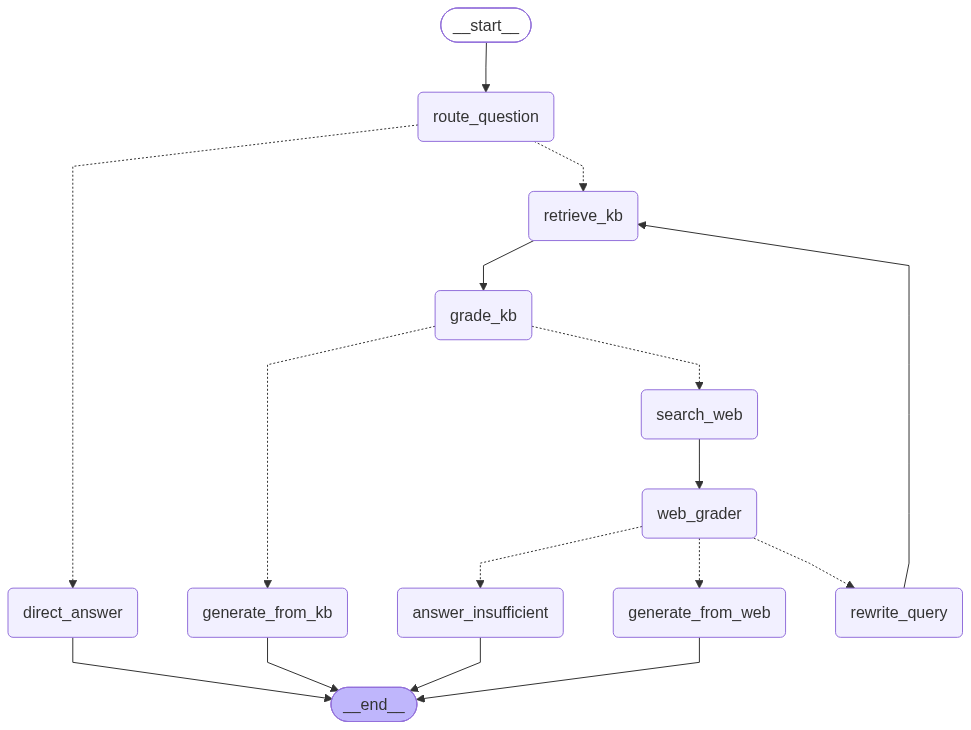

In [87]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is optional. The graph can still run.")
    print("Reason:", e)

In [88]:
def ask_agent(question:str):
    initial_state:AgenticState={
         "question": question,
        "route": "direct",
        "current_query": question,
        "kb_docs": [],
        "web_results": "",
        "kb_grade": "",
        "web_grade": "",
        "answer": "",
        "source_used": "",
        "retry_count": 0,
    }

    result = graph.invoke(initial_state)

    print("\n" + "=" * 90)
    print("QUESTION:")
    print(question)
    print("\nSOURCE USED:")
    print(result["source_used"])
    print("\nFINAL ANSWER:")
    print(result["answer"])
    print("=" * 90)

    return result
        
    
    

In [ ]:
result = ask_agent(
    "In Agentic RAG, what happens when retrieved documents are not relevant?"
)

[Router] kb
[KB Retriever] Query: In Agentic RAG, what happens when retrieved documents are not relevant?
[KB Retriever] Retrieved: 4 chunks
bad
Tavily search query:In Agentic RAG, what happens when retrieved documents are not relevant?


TypeError: BaseTool.invoke() missing 1 required positional argument: 'input'

: 

In [ ]:
result = ask_agent(
    "What is Tavily Search and why is it useful for AI agents and RAG workflows?"
)

[Router] kb

QUESTION:
What is Tavily Search and why is it useful for AI agents and RAG workflows?

SOURCE USED:
direct

FINAL ANSWER:
Tavily Search is a web‑search API that pulls fresh, curated results (and sometimes structured data) from the internet.  
For AI agents it gives a quick, reliable way to fetch up‑to‑date facts or verify claims.  
In RAG (Retrieval‑Augmented Generation) workflows it supplies the “retrieval” step—providing relevant documents or snippets that the language model can cite, which cuts hallucinations and keeps answers grounded in real‑world data.


In [ ]:
result = ask_agent("Hello, how are you?")

[Router] direct

QUESTION:
Hello, how are you?

SOURCE USED:
direct

FINAL ANSWER:
Hi! I'm doing well, thanks. How about you?


In [ ]:
ask_agent('what is agentic rag')

[Router] kb

QUESTION:
what is agentic rag

SOURCE USED:
direct

FINAL ANSWER:
Agentic RAG is a way to combine Retrieval‑Augmented Generation (RAG) with an “agent” that can plan, reason, and act on the retrieved information. Instead of just pulling in facts and generating a response, the agent can decide what to retrieve, how to use it, and even take actions (like calling APIs or updating a database) to achieve a goal. It’s basically RAG with a little extra agency.


{'question': 'what is agentic rag',
 'current_query': 'what is agentic rag',
 'kb_docs': [],
 'kb_grade': '',
 'web_grade': '',
 'answer': 'Agentic RAG is a way to combine Retrieval‑Augmented Generation (RAG) with an “agent” that can plan, reason, and act on the retrieved information. Instead of just pulling in facts and generating a response, the agent can decide what to retrieve, how to use it, and even take actions (like calling APIs or updating a database) to achieve a goal. It’s basically RAG with a little extra agency.',
 'source_used': 'direct',
 'retry_count': 0}

In [ ]:
ask_agent("How does the LangGraph agent decide whether to search the knowledge base or answer directly")

[Router] kb

QUESTION:
How does the LangGraph agent decide whether to search the knowledge base or answer directly

SOURCE USED:
direct

FINAL ANSWER:
LangGraph agents use a simple “policy node” that looks at the question and the model’s confidence.  
- If the question is about a specific fact or the model’s confidence is low, the policy fires a **search** node that pulls in relevant docs from the knowledge base.  
- If the model is confident or the question is general, the policy goes straight to the **answer** node and the LLM generates a reply from the context it already has.  

In practice this is often a learned or rule‑based threshold on the LLM’s log‑probabilities, but the idea is the same: decide “search or answer” based on confidence and the need for external facts.


{'question': 'How does the LangGraph agent decide whether to search the knowledge base or answer directly',
 'current_query': 'How does the LangGraph agent decide whether to search the knowledge base or answer directly',
 'kb_docs': [],
 'kb_grade': '',
 'web_grade': '',
 'answer': 'LangGraph agents use a simple “policy node” that looks at the question and the model’s confidence.  \n- If the question is about a specific fact or the model’s confidence is low, the policy fires a **search** node that pulls in relevant docs from the knowledge base.  \n- If the model is confident or the question is general, the policy goes straight to the **answer** node and the LLM generates a reply from the context it already has.  \n\nIn practice this is often a learned or rule‑based threshold on the LLM’s log‑probabilities, but the idea is the same: decide “search or answer” based on confidence and the need for external facts.',
 'source_used': 'direct',
 'retry_count': 0}

In [ ]:
ask_agent("What does the LangGraph agentic RAG tutorial say about creating a retriever tool?")

[Router] kb

QUESTION:
What does the LangGraph agentic RAG tutorial say about creating a retriever tool?

SOURCE USED:
direct

FINAL ANSWER:
In the LangGraph agentic RAG tutorial, the retriever tool is created by wrapping the vector‑store’s retriever in a LangGraph tool.  
You define a small function that takes a query string, calls `vectorstore.as_retriever()` (or a custom retriever) to fetch the top‑k relevant documents, and returns those documents (or their snippets). Then you register that function as a tool in the agent’s tool list. This lets the agent ask the retriever for context whenever it needs external knowledge.


{'question': 'What does the LangGraph agentic RAG tutorial say about creating a retriever tool?',
 'current_query': 'What does the LangGraph agentic RAG tutorial say about creating a retriever tool?',
 'kb_docs': [],
 'kb_grade': '',
 'web_grade': '',
 'answer': 'In the LangGraph agentic RAG tutorial, the retriever tool is created by wrapping the vector‑store’s retriever in a LangGraph tool.  \nYou define a small function that takes a query string, calls `vectorstore.as_retriever()` (or a custom retriever) to fetch the top‑k relevant documents, and returns those documents (or their snippets). Then you register that function as a tool in the agent’s tool list. This lets the agent ask the retriever for context whenever it needs external knowledge.',
 'source_used': 'direct',
 'retry_count': 0}

In [ ]:
ask_agent(" more accurate question to test with your KB is: “What function is used to retrieve documents, and how many documents does it retrieve?”")

[Router] kb

QUESTION:
 more accurate question to test with your KB is: “What function is used to retrieve documents, and how many documents does it retrieve?”

SOURCE USED:
direct

FINAL ANSWER:
The function is `retrieve_documents()` and it pulls 10 documents.


{'question': ' more accurate question to test with your KB is: “What function is used to retrieve documents, and how many documents does it retrieve?”',
 'current_query': ' more accurate question to test with your KB is: “What function is used to retrieve documents, and how many documents does it retrieve?”',
 'kb_docs': [],
 'kb_grade': '',
 'web_grade': '',
 'answer': 'The function is `retrieve_documents()` and it pulls 10 documents.',
 'source_used': 'direct',
 'retry_count': 0}

In [ ]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from hashlib import sha256

BOOK_SOURCE_URL = "https://www.gutenberg.org/cache/epub/1342/pg1342.txt"
BOOK_INDEX_NAME = "industry-pride-and-prejudice-kb"
BOOK_NAMESPACE = "pride-and-prejudice"

book_loader = WebBaseLoader(
    web_paths=(BOOK_SOURCE_URL,),
    requests_kwargs={
        "headers": {"User-Agent": "Mozilla/5.0 Agentic-RAG-Industry-Demo"},
        "timeout": 30,
    },
)
book_docs = book_loader.load()
if not book_docs or not any(doc.page_content.strip() for doc in book_docs):
    raise RuntimeError(f"No text was loaded from {BOOK_SOURCE_URL}")

book_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    add_start_index=True,
)
book_chunks = book_splitter.split_documents(book_docs)
if not book_chunks:
    raise RuntimeError("The book loader returned no chunks to index")

book_ids = [
    sha256(
        f"{BOOK_SOURCE_URL}:{chunk.metadata.get('start_index', i)}:{chunk.page_content}".encode("utf-8")
    ).hexdigest()
    for i, chunk in enumerate(book_chunks)
]

book_indexes = [index_info["name"] for index_info in pc.list_indexes()]
if BOOK_INDEX_NAME not in book_indexes:
    pc.create_index(
        name=BOOK_INDEX_NAME,
        dimension=384,
        metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1"),
    )
    while not pc.describe_index(BOOK_INDEX_NAME).status["ready"]:
        time.sleep(1)

book_vectorstore = PineconeVectorStore.from_documents(
    documents=book_chunks,
    embedding=embeddings,
    ids=book_ids,
    index_name=BOOK_INDEX_NAME,
    namespace=BOOK_NAMESPACE,
)
book_retriever = book_vectorstore.as_retriever(
    search_kwargs={"k": 4, "namespace": BOOK_NAMESPACE}
)

print("Loaded book chunks:", len(book_chunks))
print("Stored in separate Pinecone index:", BOOK_INDEX_NAME)
print("Namespace:", BOOK_NAMESPACE)